<center> <img src=https://upload.wikimedia.org/wikipedia/commons/thumb/c/ca/Water_Droplet.svg/1280px-Water_Droplet.svg.png width="400" height="200" /> <center>

# <center> Машинное обучение для прогнозирования уровня грунтовых вод с учётом климатических факторов, типа водоносного горизонта и глубины промерзания почв <center>




Подземные воды являются важнейшим источником пресной воды. 
Динамика уровня ГВ зависит от климатических факторов, промерзания почвы и характеристик водоносного горизонта.

**Цель:** построить ML-модель для прогноза месячного уровня грунтовых вод и проверить переносимость модели на другой климатический регион.

**Техническая задача:** 

**Основные цели проекта:**


> Подробное описание проекта и результаты см. в [README](../README.md)

Импорт базовых библиотек:

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# 1. Анализ и обработка данных


## 1.1 Скважина расположенная в штате Небраска 

### 1.1.1 Обработка и очистка данных

In [96]:
# Загружаем файл с данными о глубина до зеркала воды в скважине (Небраска)

# Пропускаем строки метаданных (все строки начинающиеся с #)
df_nb = pd.read_csv('../data/404618098504401_Nebraska.txt', 
                 sep="\t", 
                 comment="#",
                 skiprows=1)  # пропускаем первую строку 

In [97]:
df_nb.head(3)

,agency_cd,site_no,site_tp_cd,lev_dt,lev_tm,lev_tz_cd,lev_va,sl_lev_va,sl_datum_cd,lev_status_cd,lev_agency_cd,lev_dt_acy_cd,lev_acy_cd,lev_src_cd,lev_meth_cd,lev_age_cd,parameter_cd
0,5s,15s,6s,10d,5d,5s,12s,12s,10s,1s,5s,1s,1s,1s,1s,1s,5s
1,USGS,404618098504401,GW,1946-07-26,NaN,NaN,NaN,2040.15,NGVD29,1,NaN,D,2,NaN,S,A,62610
2,USGS,404618098504401,GW,1946-07-26,NaN,NaN,NaN,2041.00,NAVD88,1,NaN,D,2,NaN,S,A,62611


In [98]:
# Выберем только нужные столбцы и переименуем для удобства
df_val_nb = df_nb[['lev_dt','lev_va']]
df_val_nb = df_val_nb.rename(columns={"lev_va": "depth_feet", "lev_dt": "date"})
df_val_nb.head(3)

,date,depth_feet
0,10d,12s
1,1946-07-26,NaN
2,1946-07-26,NaN


In [99]:
df_val_nb.shape

(10993, 2)

In [100]:
# Удаляем первую строку, которая содержит заголовок
df_val_nb.drop(index=[0], inplace=True)

In [101]:
# Преобразуем дату и глубину
df_val_nb['date'] = pd.to_datetime(df_val_nb['date'])
df_val_nb['depth_feet'] = df_val_nb['depth_feet'].astype(float)
df_val_nb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10992 entries, 1 to 10992
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        10992 non-null  datetime64[ns]
 1   depth_feet  3664 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 171.9 KB


In [102]:
df_val_nb.isna().sum()

date             0
depth_feet    7328
dtype: int64

In [103]:
# Удаляем строки с NaN
df_val_nb.dropna(inplace=True)
df_val_nb.shape

(3664, 2)

In [104]:
# Проверяем на нули
df_val_nb['depth_feet'].eq(0).sum()

np.int64(0)

In [105]:
df_val_nb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3664 entries, 3 to 10992
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        3664 non-null   datetime64[ns]
 1   depth_feet  3664 non-null   float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 85.9 KB


In [106]:
df_val_nb.describe()

,date,depth_feet
count,3664,3664.000000
mean,1973-03-17 16:01:42.183406096,22.384716
min,1946-07-26 00:00:00,11.710000
25%,1960-07-18 18:00:00,20.657500
50%,1972-11-23 00:00:00,22.690000
75%,1984-09-07 00:00:00,24.650000
max,2025-06-12 00:00:00,29.220000
std,NaN,3.123981


In [107]:
# Переводим глубину из футов в метры
df_val_nb['depth_m'] = df_val_nb['depth_feet'] * 0.3048

In [108]:
# Создаём месячную агрегированную таблицу (средняя глубина по месяцам)
df_val_nb['year'] = df_val_nb['date'].dt.year
df_val_nb['month'] = df_val_nb['date'].dt.month
monthly_nb = df_val_nb.groupby(['year', 'month'])['depth_m'].mean().reset_index()
monthly_nb.head(3)

,year,month,depth_m
0,1946,7,6.111240
1,1946,8,5.888736
2,1946,9,6.031992


In [109]:
# Добавляем cтолбец с датой первого числа месяца
monthly_nb['month_start'] = pd.to_datetime(monthly_nb[['year', 'month']].assign(day=1))
monthly_nb.head(3)

,year,month,depth_m,month_start
0,1946,7,6.111240,1946-07-01
1,1946,8,5.888736,1946-08-01
2,1946,9,6.031992,1946-09-01


In [110]:
# Считаем количество месяцев по годам
year_counts = monthly_nb.groupby('year').size().reset_index(name='months_count')
# Оставляем только года с 6+ месяцами
valid_years = year_counts[year_counts['months_count'] >= 6]['year']
monthly_nb_filtered = monthly_nb[monthly_nb['year'].isin(valid_years)].copy()
print(f"Было: {len(monthly_nb)} строк")
print(f"Стало: {len(monthly_nb_filtered)} строк")
print(f"Удаленно лет: {len(set(monthly_nb['year'].unique())) - len(set(valid_years))}")
print()

Было: 797 строк
Стало: 750 строк
Удаленно лет: 14



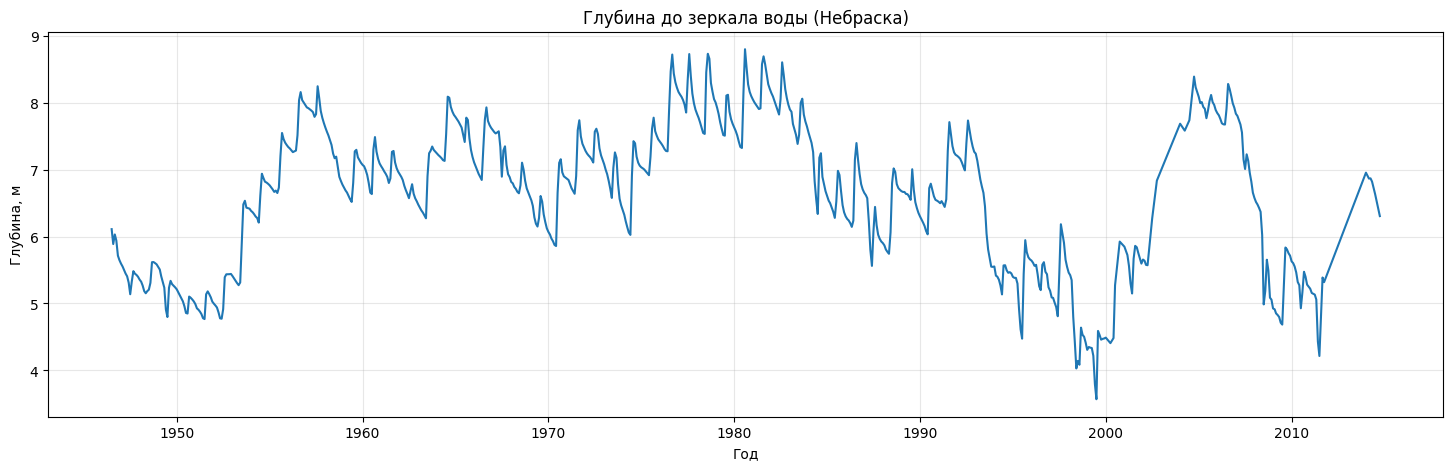

In [111]:
# Визуализируем данные о глубина до зеркала воды в метрах (Небраска) после очистки данных
plt.rcParams["figure.figsize"] = 18, 5
plt.plot(monthly_nb_filtered['month_start'], monthly_nb_filtered["depth_m"])
plt.title("Глубина до зеркала воды (Небраска)")
plt.xlabel("Год")
plt.ylabel("Глубина, м")
plt.grid(True, alpha=0.3)
plt.show()

In [112]:
print('Год начала данных:', monthly_nb_filtered['year'].max())
print('Год окончания данных:', monthly_nb_filtered['year'].min())
print('Глубина до зеркала воды min:', round(monthly_nb_filtered['depth_m'].min(), 2))
print('Глубина до зеркала воды max:', round(monthly_nb_filtered['depth_m'].max(), 2))
print('Глубина до зеркала воды mean:', round(monthly_nb_filtered['depth_m'].mean(), 2))

Год начала данных: 2014
Год окончания данных: 1946
Глубина до зеркала воды min: 3.57
Глубина до зеркала воды max: 8.8
Глубина до зеркала воды mean: 6.61


Данные по скважине в штате Небраска охватывают период с 1946 по 2014 год — почти 68 лет непрерывных наблюдений. Это один из наиболее длительных рядов данных об уровне грунтовых вод, что делает его идеальным для анализа долгосрочных климатических трендов и построения прогностических моделей.

Глубина до зеркала воды варьируется от 3.57 до 8.80 метров относительно поверхности земли, при среднем значении 6.61 метров. Такой широкий диапазон (более 5 метров) свидетельствует о значительной сезонной и многолетней изменчивости уровня грунтовых вод. 

In [113]:
# Загружаем файл с данными о температуре воздуха и осадках в районе скважины (Небраска)

# Загружаем ERA5 данные
ds_temp_nb = xr.open_dataset("../data/era5_temp_combined_Nebraska.nc")
ds_precip_nb = xr.open_dataset("../data/era5_precip_combined_Nebraska.nc")

In [114]:
# Для каждой даты valid_time выбираем первое не-NaN значение
def extract_monthly_values(ds, var_name):
    """Извлекает месячные значения из сложной структуры ERA5"""
    values = []
    dates = []
    
    for vt in ds.valid_time.values:
        # Выбираем данные для этой valid_time
        subset = ds[var_name].sel(valid_time=vt)
        
        # Находим первое не-NaN значение
        non_nan = subset.where(~np.isnan(subset), drop=True)
        
        if len(non_nan) > 0:
            # Усредняем по lat/lon и берем значение
            val = non_nan.mean(dim=['latitude', 'longitude']).values
            # Берем скалярное значение
            values.append(val.item() if hasattr(val, 'item') else float(val))
            dates.append(vt)
        else:
            print(f"Нет данных для {vt}")
    
    return np.array(values), np.array(dates)

# Извлекаем значения
temp_values_nb, temp_dates_nb = extract_monthly_values(ds_temp_nb, 't2m')
precip_values_nb, precip_dates_nb = extract_monthly_values(ds_precip_nb, 'tp')
print("Температура (месяцев):", len(temp_values_nb))
print("Осадки (месяцев):", len(precip_values_nb)) 

Температура (месяцев): 960
Осадки (месяцев): 960


In [ ]:
# Создаем DataFrame с данными о температуре (Небраска) 
df_temp_nb = pd.DataFrame({
    'temp_dates': pd.to_datetime(temp_dates_nb).strftime('%Y-%m-%d'),
    'temp_C': temp_values_nb - 273.15   # K -> °C
})
df_temp_nb.head()


,precip_dates,precip_mm
0,1946-01-01,0.415590
1,1946-02-01,0.277837
2,1946-03-01,3.648758
3,1946-04-01,1.001358
4,1946-05-01,3.700256


In [115]:
# Создаем DataFrame с данными об осадках (Небраска) 
df_precip_nb = pd.DataFrame({
    'precip_dates': pd.to_datetime(precip_dates_nb).strftime('%Y-%m-%d'),
    'precip_mm': precip_values_nb * 1000 # м -> мм
})
df_precip_nb.head()

,precip_dates,precip_mm
0,1946-01-01,0.415590
1,1946-02-01,0.277837
2,1946-03-01,3.648758
3,1946-04-01,1.001358
4,1946-05-01,3.700256


In [ ]:
# Объединяем все данные о погоде в один DataFrame (Небраска)
df_weather_nb_all = monthly_nb_filtered.copy()
df_weather_nb_all['temp_C'] = df_temp_nb.set_index('temp_dates')['temp_C'].reindex(df_weather_nb_all['month_start'].dt.strftime('%Y-%m-%d')).values
df_weather_nb_all['precip_mm'] = df_precip_nb.set_index('precip_dates')['precip_mm'].reindex(df_weather_nb_all['month_start'].dt.strftime('%Y-%m-%d')).values

df_weather_nb_all.head()

,year,month,depth_m,month_start,temp_C,precip_mm
0,1946,7,6.111240,1946-07-01,23.500055,1.392365
1,1946,8,5.888736,1946-08-01,22.624689,1.212226
2,1946,9,6.031992,1946-09-01,18.256616,4.319509
3,1946,10,5.940552,1946-10-01,12.009393,4.212273
4,1946,11,5.714492,1946-11-01,1.217126,2.452533
